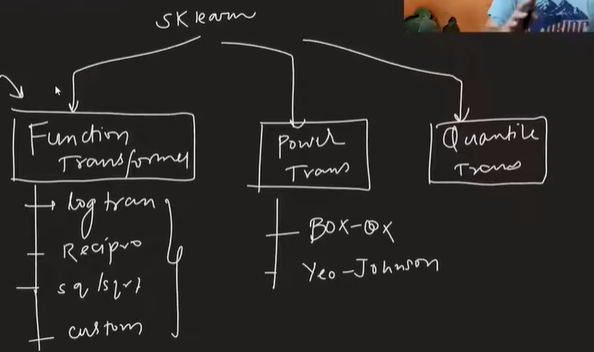

# QQ PLOTS
## A qq plot is drawn. the more the deviation from y=x line, it isnt in normal distribution


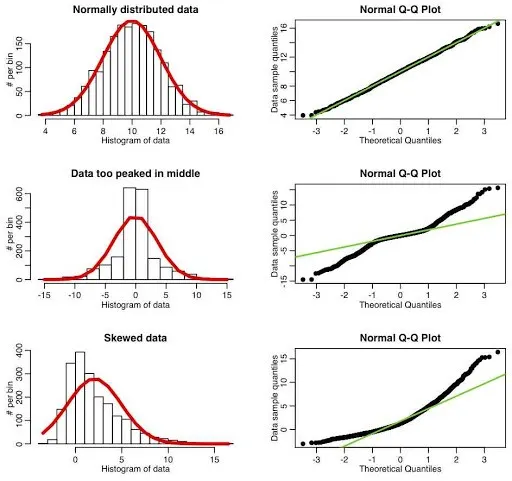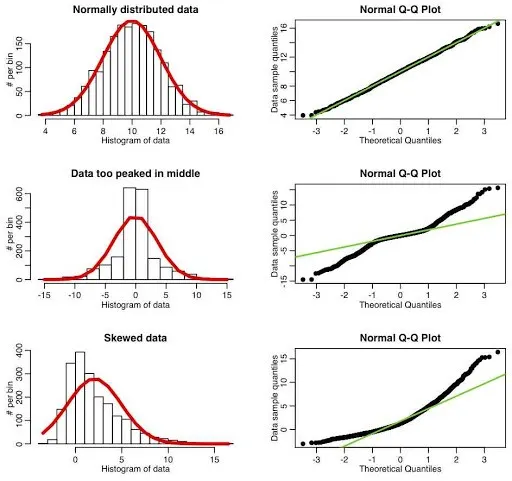

# Log Transform

# Reciprocal transform: 
x-> 1/x

# Square/square root transform

x-> x^2 (used for left skewed data)

x-> sqrt(x)

In [3]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])
df.sample(5)

,Survived,Age,Fare
167,0,45.0,27.9000
731,0,11.0,18.7875
695,0,52.0,13.5000
460,1,48.0,26.5500
303,1,NaN,12.3500


In [5]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [6]:
# Age has missing values

In [7]:
from sklearn.impute import SimpleImputer

In [8]:
imputer = SimpleImputer(strategy='mean')
df[['Age']] = imputer.fit_transform(df[['Age']])

In [9]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [10]:
# null values filled
# Train test split

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(df[['Age','Fare']],df[['Survived']],test_size=0.2,random_state=42)

In [13]:
x_train.sample(3)

,Age,Fare
58,5.000000,27.75
674,29.699118,0.00
347,29.699118,16.10


In [14]:
# check distribution
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

C:\Users\Dell\AppData\Local\Temp\ipykernel_8560\1159061026.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Age'])


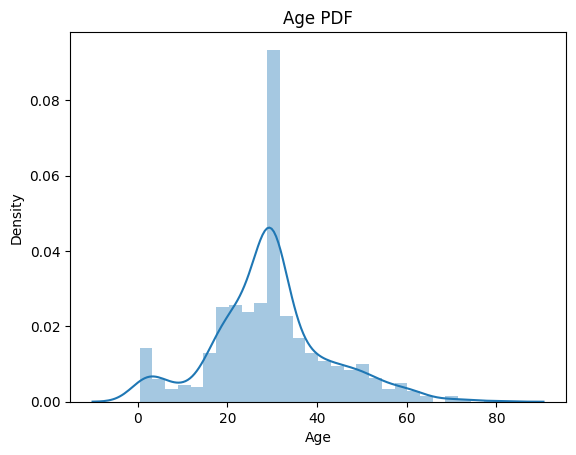

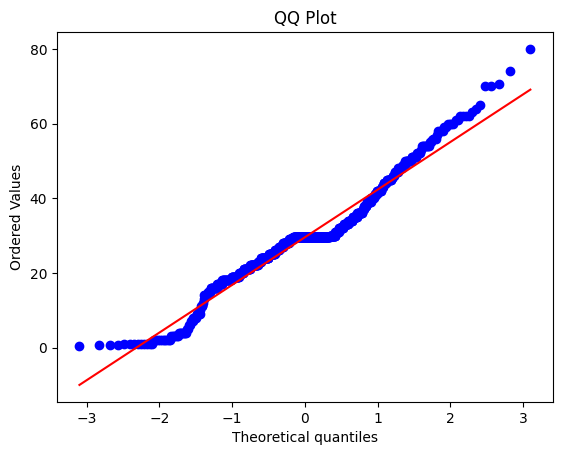

In [15]:
sns.distplot(x_train['Age'])
plt.title('Age PDF')
plt.show()
# Not in normal dis
stats.probplot(x_train['Age'],dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_8560\160754251.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train['Fare'])


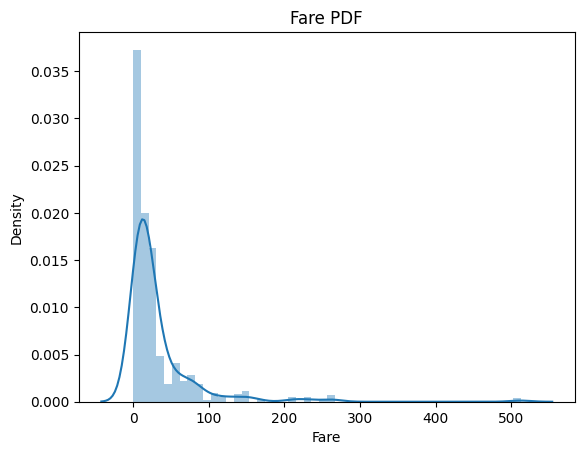

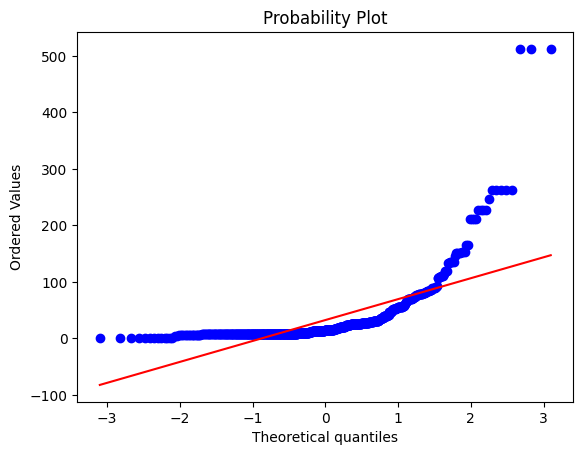

In [16]:
sns.distplot(x_train['Fare'])
# right skewed
plt.title('Fare PDF')
plt.show()
# Not in normal dis
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.show()


In [17]:
# lets find accuracy first without converting into normal distribution
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [18]:
clf=DecisionTreeClassifier()
lr=LogisticRegression()

In [19]:
clf.fit(x_train,y_train)
lr.fit(x_train,y_train)

C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
y_pred=clf.predict(x_test)
y_pred1=lr.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score

In [22]:
print('Decision tree',accuracy_score(y_test,y_pred))
print('LogisticReg',accuracy_score(y_test,y_pred1))

Decision tree 0.6759776536312849
LogisticReg 0.6480446927374302


# Using log transform

In [23]:
from sklearn.preprocessing import FunctionTransformer

In [24]:
trf=FunctionTransformer(func=np.log1p)

In [27]:
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [28]:
clf.fit(x_train_transformed,y_train)
lr.fit(x_train_transformed,y_train)

C:\Users\Dell\Downloads\anaconda\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
y_pred1=clf.predict(x_test_transformed)
y_pred2=clf.predict(x_test_transformed)

In [33]:
print('decision tree',accuracy_score(y_test,y_pred1))
print('logistic regression',accuracy_score(y_test,y_pred2))

decision tree 0.6983240223463687
logistic regression 0.6983240223463687


In [34]:
# we can see improvement from previous data

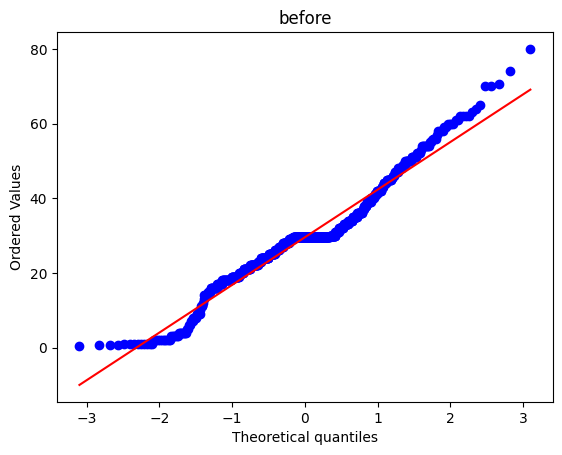

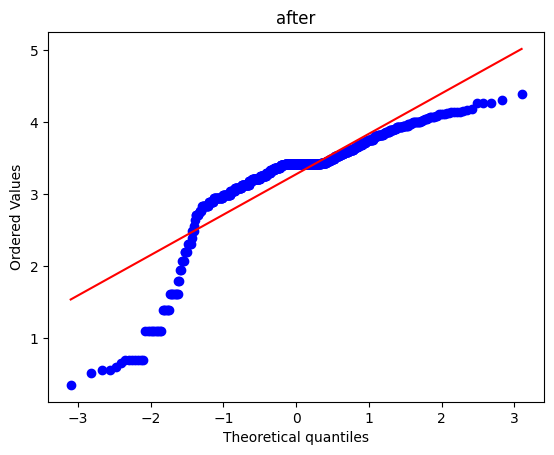

In [41]:
# comparsion
stats.probplot(x_train['Age'],dist='norm',plot=plt)
plt.title('before')
plt.show()
stats.probplot(x_train_transformed['Age'],dist='norm',plot=plt)
plt.title('after')
plt.show()

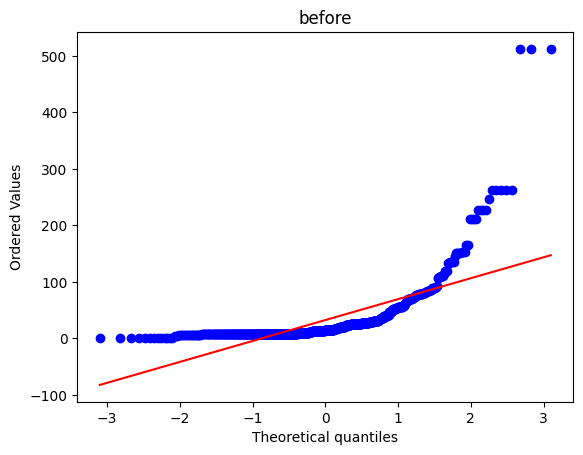

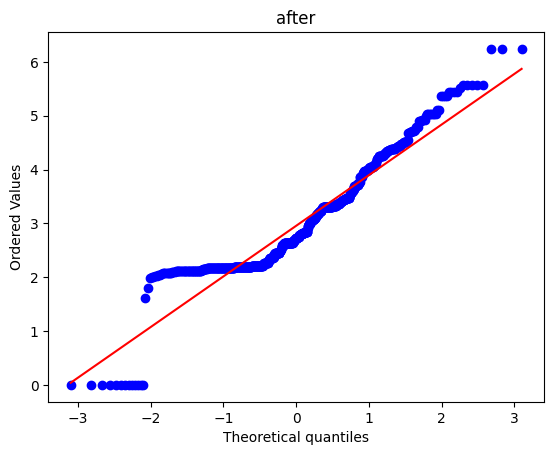

In [42]:
# comparsion
stats.probplot(x_train['Fare'],dist='norm',plot=plt)
plt.title('before')
plt.show()
stats.probplot(x_train_transformed['Fare'],dist='norm',plot=plt)
plt.title('after')
plt.show()